<a href="https://colab.research.google.com/github/samitha278/EN3160-IPCV/blob/main/fitting_and_alignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import gdown
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from google.colab.patches import cv2_imshow

# 1

In [5]:
# Data file download

file_id = "1v67HJVO_KJ_O9LRwu6D0C4aKpq9IV4xm"
url = f"https://drive.google.com/uc?id={file_id}"

output = "sunflower.jpeg"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1v67HJVO_KJ_O9LRwu6D0C4aKpq9IV4xm
To: /content/sunflower.jpeg
100%|██████████| 224k/224k [00:00<00:00, 58.8MB/s]


'sunflower.jpeg'

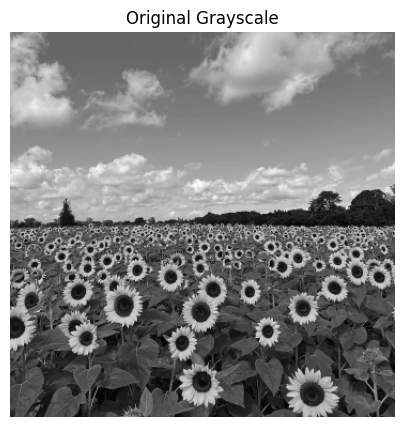

In [8]:
img = cv.imread(output, cv.IMREAD_REDUCED_COLOR_4)
assert img is not None
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY) / 255

plt.figure(figsize=(5, 5))
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.title('Original Grayscale')
plt.show()

In [12]:
sigma_min = 1
sigma_max = 15
num_scales = 15
thresh = 0.1
k = 1

sigmas = np.linspace(sigma_min, sigma_max, num_scales) / 1.414

all_blobs = []

for s in sigmas:
    print(f"{s:.2f}", end=", ")
    hw = round(3 * s)
    X, Y = np.meshgrid(np.arange(-hw, hw + 1), np.arange(-hw, hw + 1))

    # LoG kernel
    log_kernel = ((X**2 + Y**2) / (2 * s**2) - 1) * np.exp(-(X**2 + Y**2) / (2 * s**2)) / (np.pi * s**4)
    log_kernel = s**2 * log_kernel

    response = np.square(cv.filter2D(gray, -1, log_kernel))

    # Find local maxima
    H, W = response.shape
    for i in range(k, H - k):
        for j in range(k, W - k):
            patch = response[i - k:i + k + 1, j - k:j + k + 1]
            if np.max(patch) >= thresh:
                x, y = np.unravel_index(patch.argmax(), patch.shape)
                all_blobs.append((i + x - k, j + y - k, s))

print(f"\nTotal blobs: {len(all_blobs)}")

0.71, 1.41, 2.12, 2.83, 3.54, 4.24, 4.95, 5.66, 6.36, 7.07, 7.78, 8.49, 9.19, 9.90, 10.61, 
Total blobs: 1192


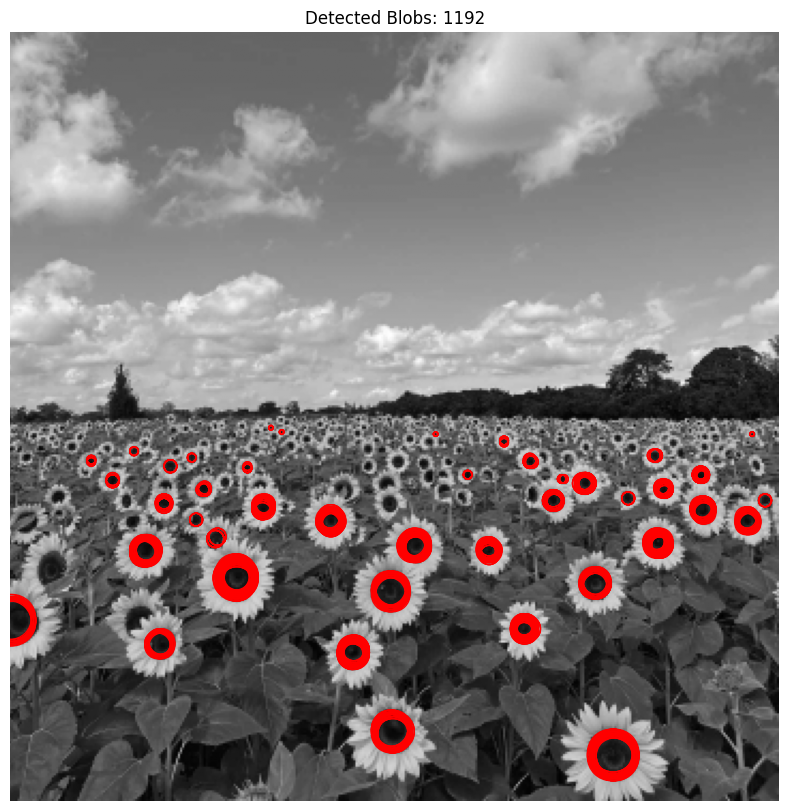

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(gray, cmap='gray')

for y, x, s in all_blobs:
    circle = plt.Circle((x, y), s * 1.414, color='r', linewidth=1, fill=False)
    ax.add_patch(circle)

ax.set_xlim([0, gray.shape[1]])
ax.set_ylim([gray.shape[0], 0])
ax.axis('off')
plt.title(f'Detected Blobs: {len(all_blobs)}')
plt.show()


σ range: [0.71, 10.61]

Top 10 Largest Circles:
Rank   Y        X        Sigma      Radius    
---------------------------------------------
1      274.0    0.0      7.78       11.00     
2      274.0    1.0      7.78       11.00     
3      275.0    0.0      7.78       11.00     
4      275.0    1.0      7.78       11.00     
5      275.0    0.0      7.78       11.00     
6      275.0    1.0      7.78       11.00     
7      275.0    0.0      7.78       11.00     
8      275.0    1.0      7.78       11.00     
9      276.0    0.0      7.78       11.00     
10     276.0    1.0      7.78       11.00     


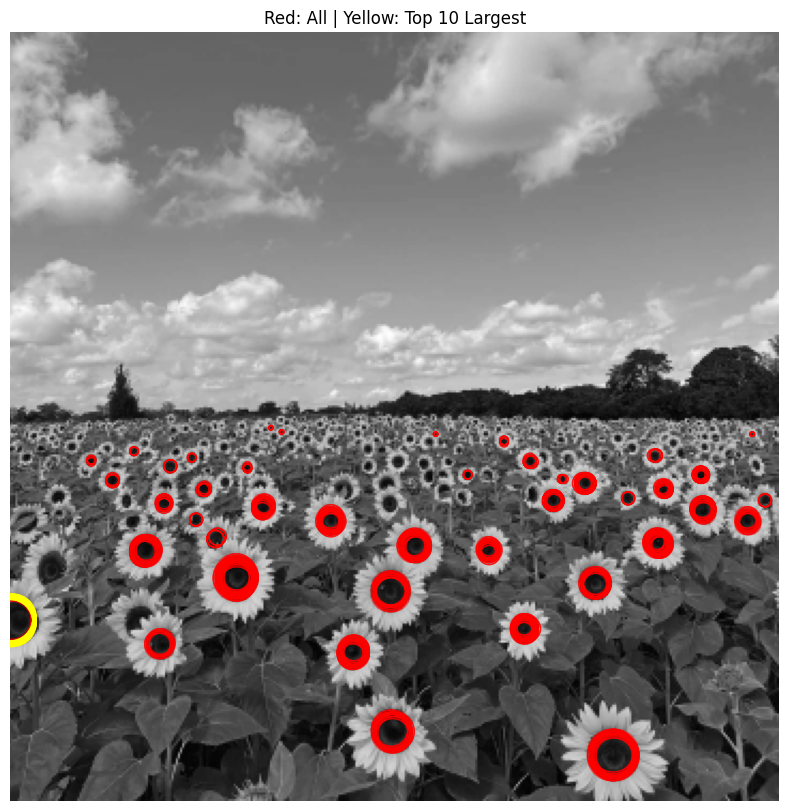

In [15]:
blobs_sorted = sorted(all_blobs, key=lambda b: b[2], reverse=True)

print(f"\nσ range: [{sigmas[0]:.2f}, {sigmas[-1]:.2f}]")
print(f"\nTop 10 Largest Circles:")
print(f"{'Rank':<6} {'Y':<8} {'X':<8} {'Sigma':<10} {'Radius':<10}")
print("-" * 45)

for i, (y, x, s) in enumerate(blobs_sorted[:10]):
    r = s * 1.414
    print(f"{i+1:<6} {y:<8.1f} {x:<8.1f} {s:<10.2f} {r:<10.2f}")

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(gray, cmap='gray')

# All blobs in red
for y, x, s in all_blobs:
    circle = plt.Circle((x, y), s * 1.414, color='r', linewidth=1, fill=False, alpha=0.5)
    ax.add_patch(circle)

# Top 10 in yellow
for y, x, s in blobs_sorted[:10]:
    circle = plt.Circle((x, y), s * 1.414, color='yellow', linewidth=2, fill=False)
    ax.add_patch(circle)

ax.set_xlim([0, gray.shape[1]])
ax.set_ylim([gray.shape[0], 0])
ax.axis('off')
plt.title('Red: All | Yellow: Top 10 Largest')
plt.show()

# 2

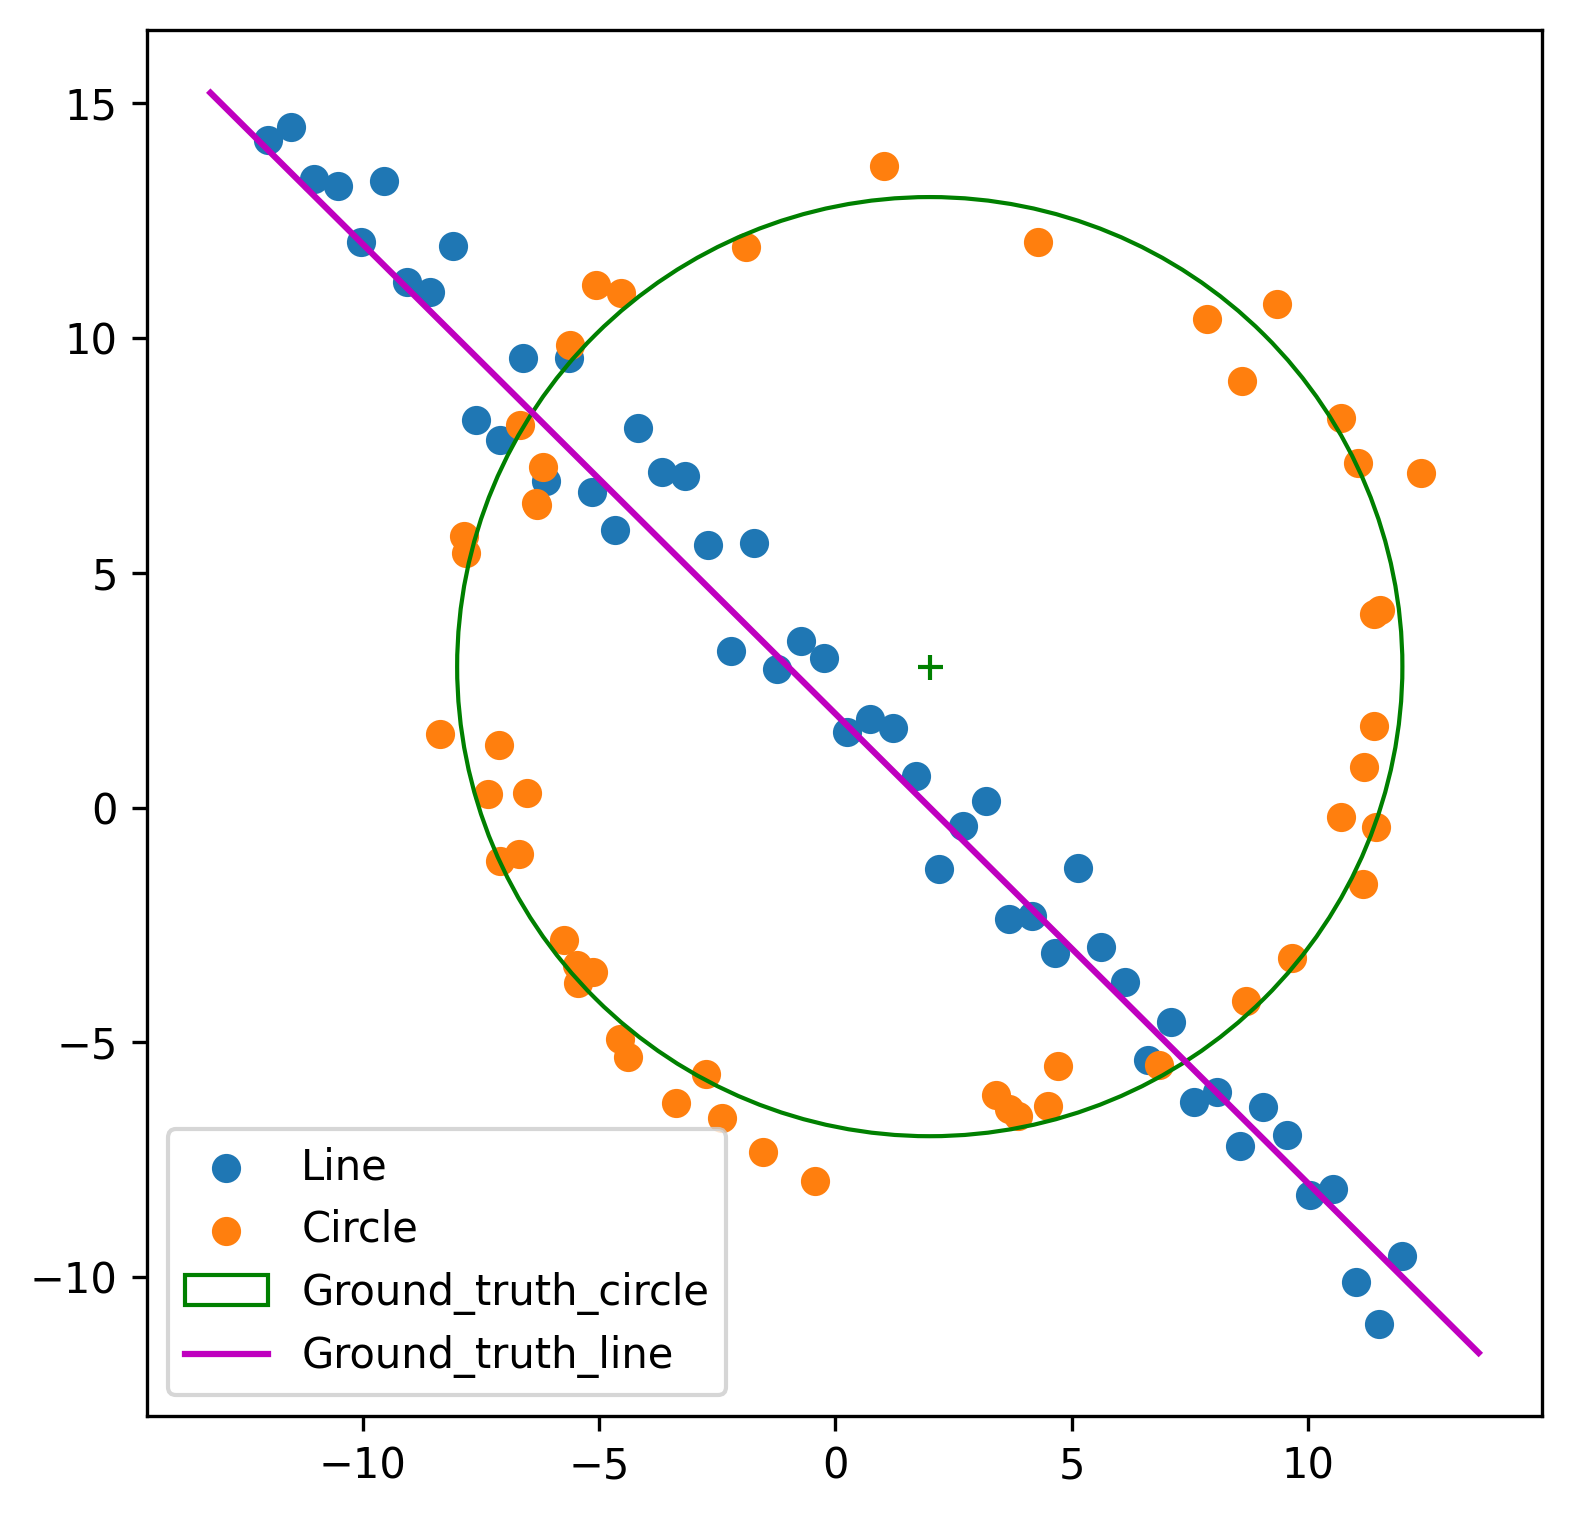

In [19]:
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(0)
N = 100
half_n = N//2

r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r/16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n,1), y.reshape(half_n,1)))
X = np.vstack((X_circ, X_line))  # All points

fig, ax = plt.subplots(1,1, figsize=(6,6), dpi=300)
ax.scatter(X_line[:,0], X_line[:,1], label='Line')
ax.scatter(X_circ[:,0], X_circ[:,1], label='Circle')
circle_gt = plt.Circle((x0_gt,y0_gt), r, color='g', fill=False, label='Ground_truth_circle')
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt.plot(x_, y_, color='m', label='Ground_truth_line')
plt.legend()

In [33]:
def fit_line_ransac(X, n_iterations=1000, threshold=0.5, min_inliers=30):

    best_inliers = []
    best_model = None
    best_error = float('inf')

    for i in range(n_iterations):

        sample_idx = np.random.choice(len(X), 2, replace=False)
        pts = X[sample_idx]

        # Fit line to sample
        direction = pts[1] - pts[0]
        normal = np.array([-direction[1], direction[0]])
        normal = normal / np.linalg.norm(normal)  # Unit normal
        a, b = normal
        d = np.dot(normal, pts[0])

        # Calculate distances
        distances = np.abs(X @ normal - d)

        # Find inliers
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(best_inliers):

            best_inliers = inliers
            best_model = (a, b, d)
            best_error = np.mean(distances[inliers])

    return best_model, best_inliers

In [34]:
def fit_circle_to_points(pts):

    x1, y1 = pts[0]
    x2, y2 = pts[1]
    x3, y3 = pts[2]

    A = np.array([
        [x1, y1, 1],
        [x2, y2, 1],
        [x3, y3, 1]
    ])

    B = np.array([
        [-(x1**2 + y1**2)],
        [-(x2**2 + y2**2)],
        [-(x3**2 + y3**2)]
    ])

    try:
        C = np.linalg.solve(A, B)
        x0 = -0.5 * C[0][0]
        y0 = -0.5 * C[1][0]
        r = np.sqrt(x0**2 + y0**2 - C[2][0])
        return x0, y0, r
    except:
        return None, None, None

In [35]:
def fit_circle_ransac(X, n_iterations=1000, threshold=0.5, min_inliers=30):

    best_inliers = []
    best_model = None

    for i in range(n_iterations):
        sample_idx = np.random.choice(len(X), 3, replace=False)
        pts = X[sample_idx]

        # Fit circle to 3 points
        x0, y0, r = fit_circle_to_points(pts)

        if x0 is None:
            continue

        # Calculate radial errors
        distances = np.abs(np.sqrt((X[:, 0] - x0)**2 +
                                   (X[:, 1] - y0)**2) - r)

        # Find inliers
        inliers = np.where(distances < threshold)[0]

        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (x0, y0, r)

    return best_model, best_inliers

In [37]:
line_model, line_inlier_idx = fit_line_ransac(X)
line_inliers = X[line_inlier_idx]
print("Number of line inliers:", len(line_inliers))
print(f"Line parameters: a={line_model[0]:.4f}, b={line_model[1]:.4f}, d={line_model[2]:.4f}")

Number of line inliers: 28
Line parameters: a=0.7562, b=0.6544, d=1.9037


In [38]:
# Remove line inliers
mask = np.ones(len(X), dtype=bool)
mask[line_inlier_idx] = False
remaining = X[mask]

circle_model, circle_inlier_idx = fit_circle_ransac(remaining)
circle_inliers = remaining[circle_inlier_idx]
print("Number of circle inliers:", len(circle_inliers))
print(f"Circle parameters: x0={circle_model[0]:.4f}, y0={circle_model[1]:.4f}, r={circle_model[2]:.4f}")

Number of circle inliers: 32
Circle parameters: x0=1.8608, y0=3.3266, r=10.0324


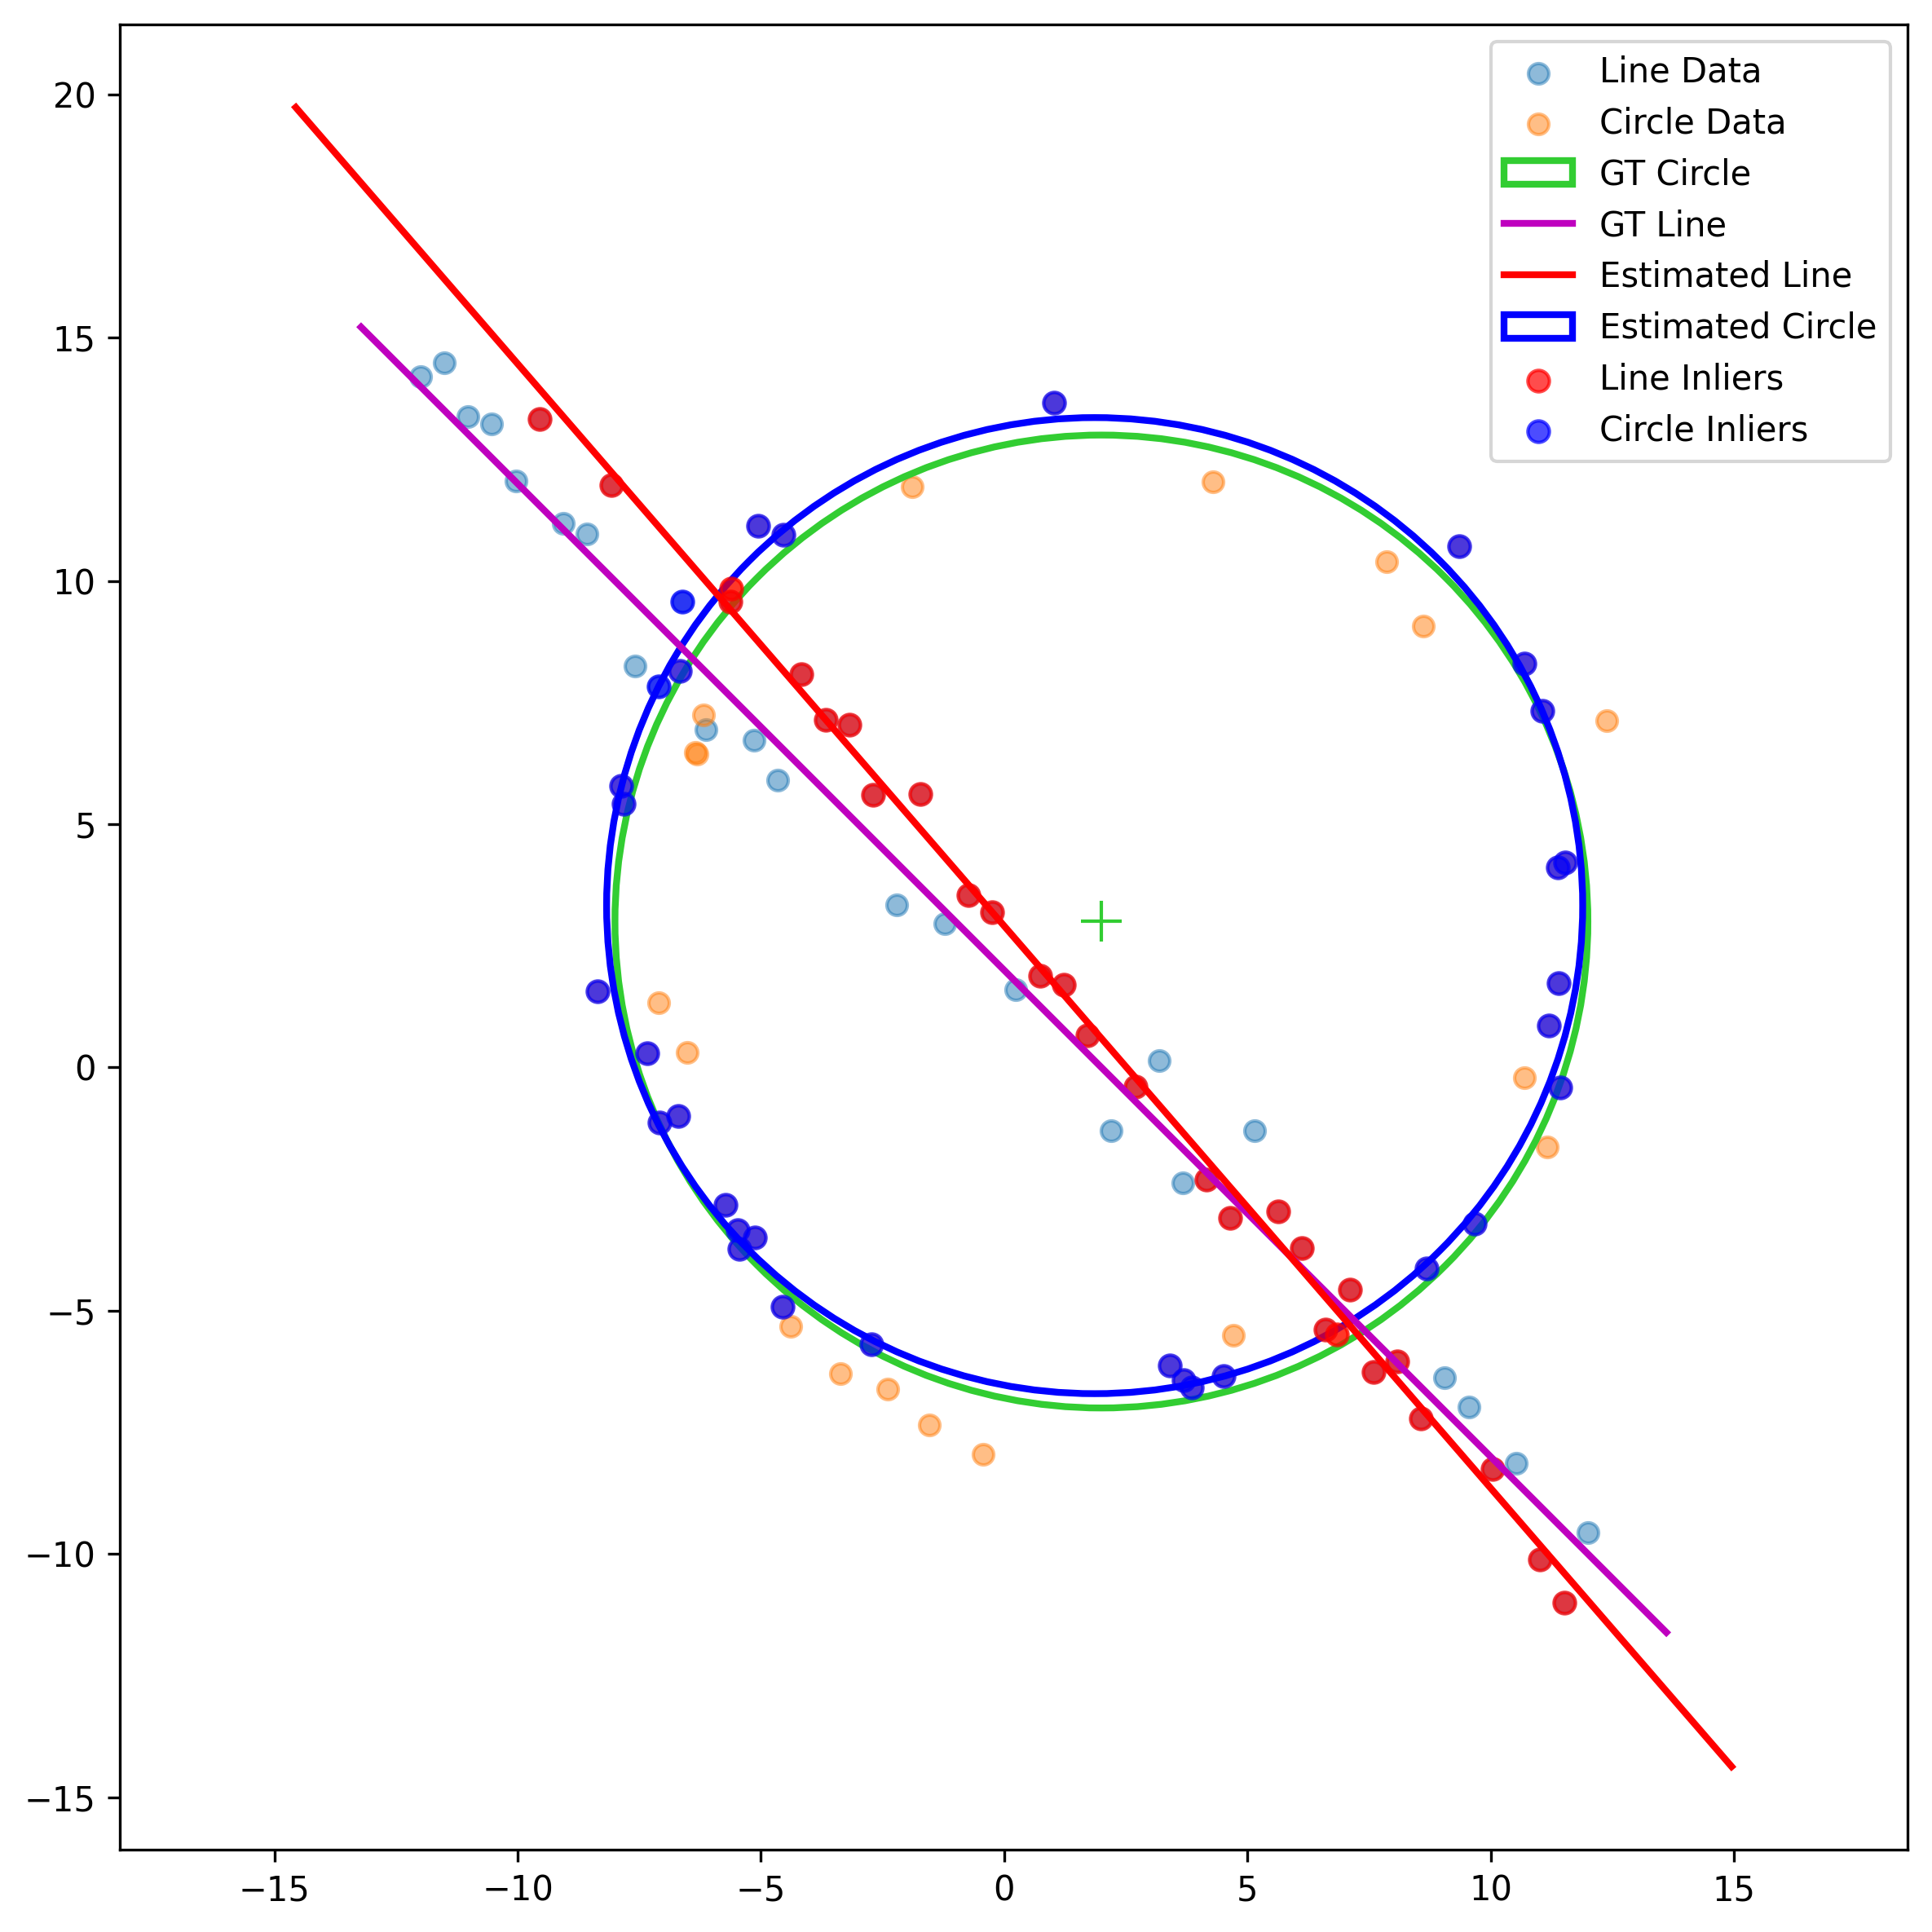

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)

# Original data
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line Data', alpha=0.5)
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle Data', alpha=0.5)

# Ground truth
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='limegreen',
                        fill=False, linewidth=2, label='GT Circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, '+', color='limegreen', markersize=12)
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b
plt.plot(x_, y_, color='m', linewidth=2, label='GT Line')

# Estimated line
a, b_param, d = line_model
x_vals = np.array(ax.get_xlim())
y_vals = (d - a * x_vals) / b_param
ax.plot(x_vals, y_vals, 'r-', linewidth=2, label='Estimated Line')

# Estimated circle
x0_est, y0_est, r_est = circle_model
circle_est = plt.Circle((x0_est, y0_est), r_est, color='b',
                         fill=False, linewidth=2, label='Estimated Circle')
ax.add_patch(circle_est)

# Inliers
ax.scatter(line_inliers[:, 0], line_inliers[:, 1],
           color='red', s=40, marker='o', label='Line Inliers', alpha=0.7)
ax.scatter(circle_inliers[:, 0], circle_inliers[:, 1],
           color='blue', s=40, marker='o', label='Circle Inliers', alpha=0.7)

ax.legend()
ax.axis('equal')
plt.tight_layout()
plt.show()

# 3

In [50]:

# Data file download
file_id = "1MXTlLGr5GdnL9WiYvtAfEjh2nxu7nZZT"

url = f"https://drive.google.com/uc?id={file_id}"

taj = "taj.png"
gdown.download(url, taj, quiet=False)




file_id = "1SIrwlo6mKsHb1JhQEofSMXOFis3Gcfyt"
url = f"https://drive.google.com/uc?id={file_id}"

sl = "sri-lanka-flag.png"
gdown.download(url, sl, quiet=False)





file_id = "1dj8fan9UozpDZPHSWO-eLJWwvLpqjsmy"
url = f"https://drive.google.com/uc?id={file_id}"

par = "par.jpeg"
gdown.download(url, par, quiet=False)




file_id = "1M7pof3bharL5kwbY4T2If_XOkqT8vGvk"
url = f"https://drive.google.com/uc?id={file_id}"

india = "india-flag.png"
gdown.download(url, india, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1MXTlLGr5GdnL9WiYvtAfEjh2nxu7nZZT
To: /content/taj.png
100%|██████████| 492k/492k [00:00<00:00, 77.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1SIrwlo6mKsHb1JhQEofSMXOFis3Gcfyt
To: /content/sri-lanka-flag.png
100%|██████████| 21.4k/21.4k [00:00<00:00, 27.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1dj8fan9UozpDZPHSWO-eLJWwvLpqjsmy
To: /content/par.jpeg
100%|██████████| 392k/392k [00:00<00:00, 74.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1M7pof3bharL5kwbY4T2If_XOkqT8vGvk
To: /content/india-flag.png
100%|██████████| 52.2k/52.2k [00:00<00:00, 45.4MB/s]


'india-flag.png'

# 1st Image

In [59]:
building = cv.imread(par)
flag = cv.imread(sl)


building_rgb = cv.cvtColor(building, cv.COLOR_BGR2RGB)
flag_rgb = cv.cvtColor(flag, cv.COLOR_BGR2RGB)

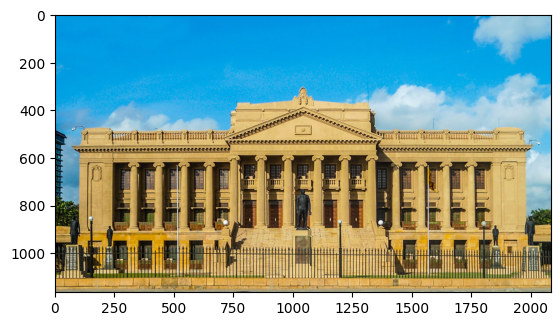

In [61]:
building_rgb = cv.cvtColor(building, cv.COLOR_BGR2RGB)
plt.imshow(building_rgb)
plt.show()

In [84]:
clicked_points = [[750,590],[1350,590],[1350,890],[750,890]]

In [85]:
# Points clicked on the building image
building_points = np.array(clicked_points, dtype=np.float32)


flag_points = np.array([
    [0, 0],
    [flag.shape[1], 0],
    [flag.shape[1], flag.shape[0]],
    [0, flag.shape[0]]
], dtype=np.float32)


homography_matrix, _ = cv.findHomography(flag_points, building_points)
warped_flag = cv.warpPerspective(flag, homography_matrix,
                                  (building.shape[1], building.shape[0]))
overlay_mask = np.zeros_like(building, dtype=np.uint8)
cv.fillConvexPoly(overlay_mask, building_points.astype(int), (255, 255, 255))

# Blend the warped flag and the building image
blended = cv.addWeighted(building, 1.0, warped_flag, 0.5, 0)


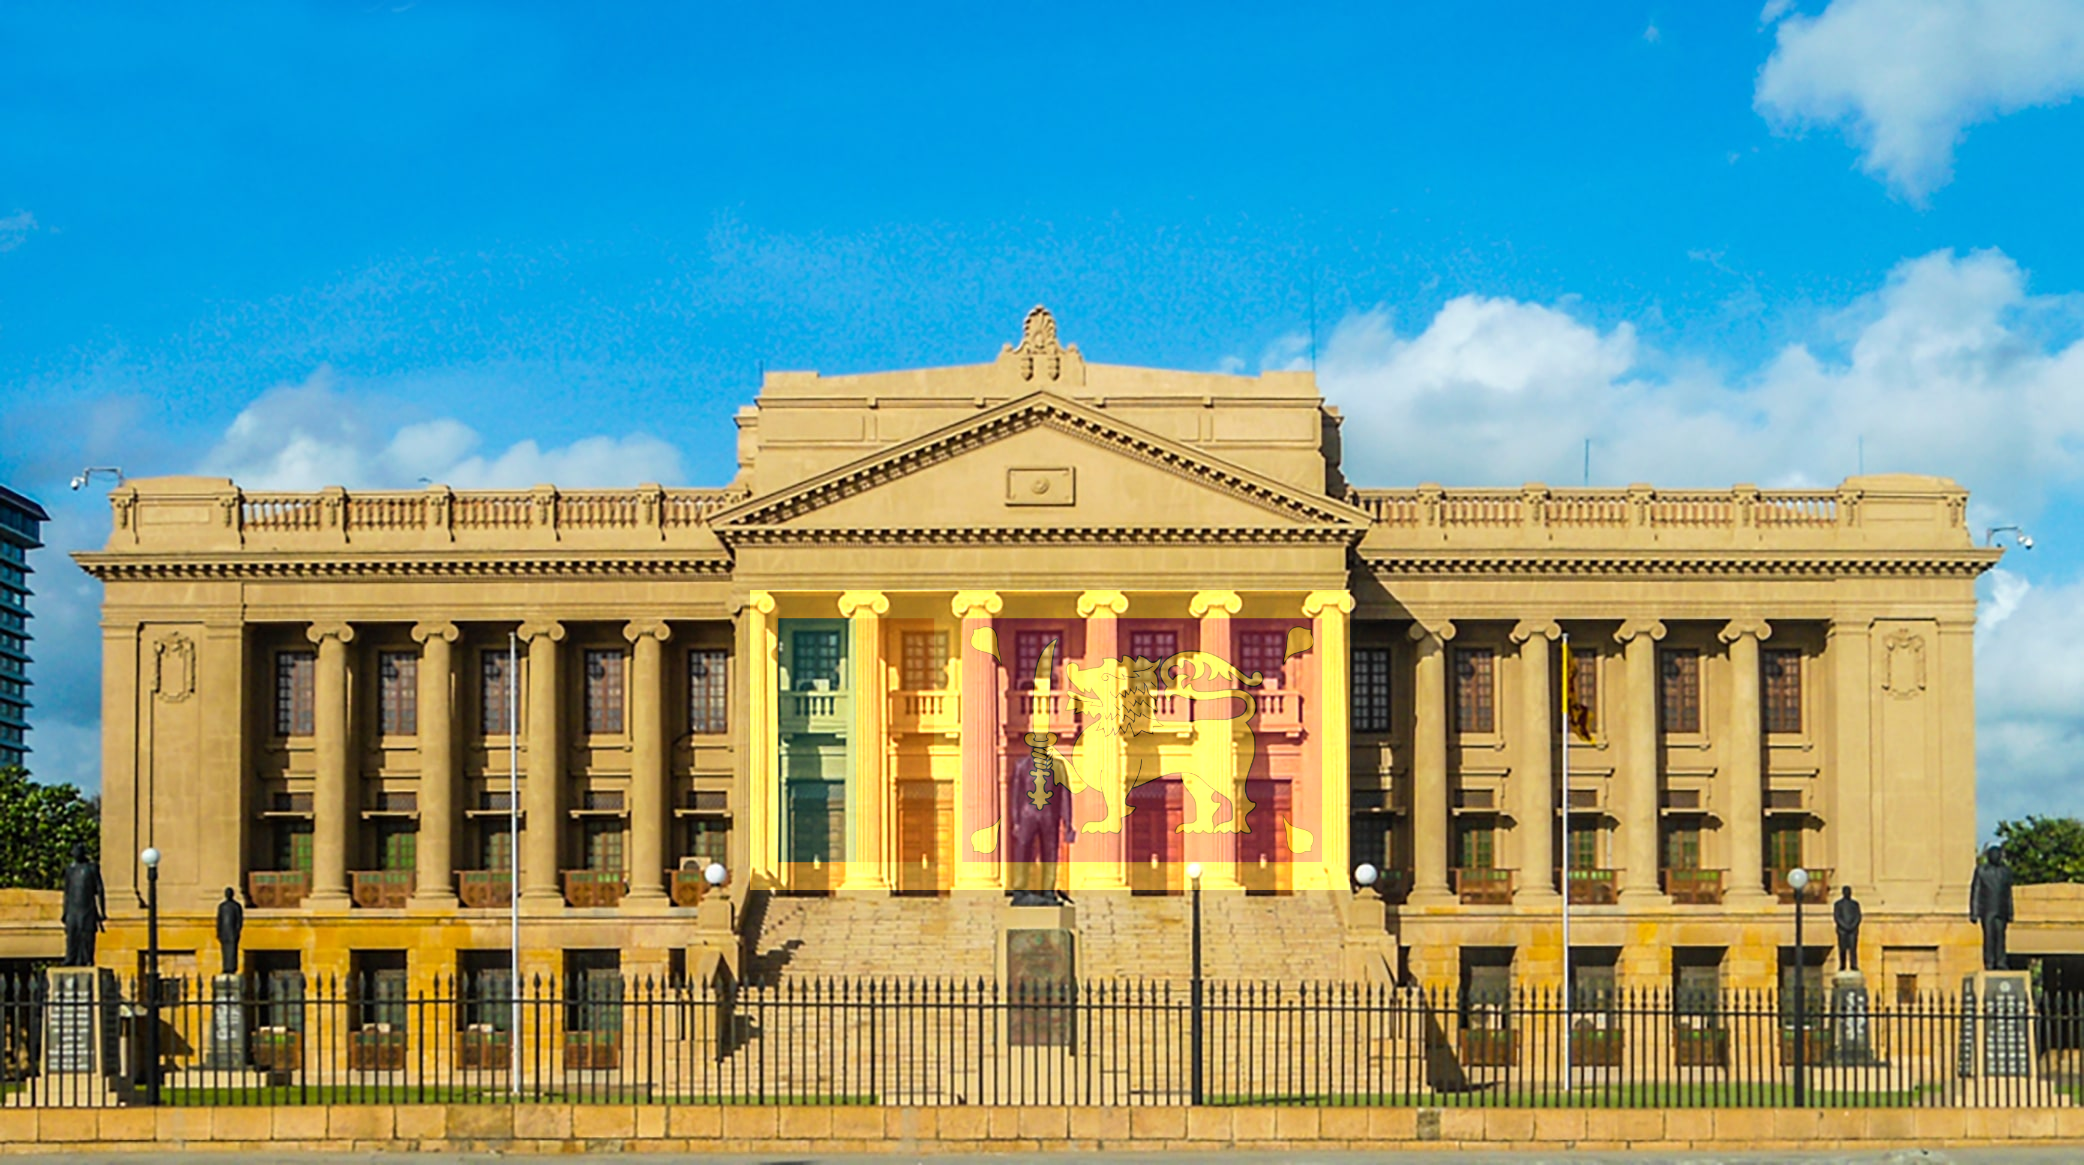

In [86]:

cv2_imshow(blended)

# 2nd Image

In [88]:
building = cv.imread(taj)
flag = cv.imread(india)


building_rgb = cv.cvtColor(building, cv.COLOR_BGR2RGB)
flag_rgb = cv.cvtColor(flag, cv.COLOR_BGR2RGB)

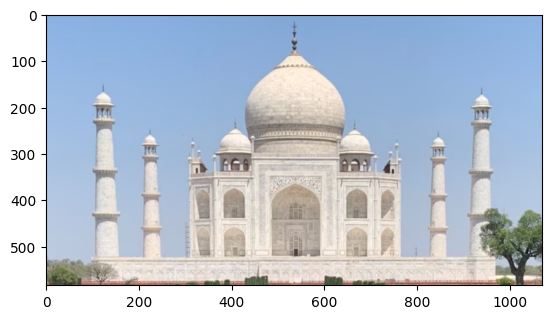

In [89]:
building_rgb = cv.cvtColor(building, cv.COLOR_BGR2RGB)
plt.imshow(building_rgb)
plt.show()

In [98]:
clicked_points = [[380,340],[720,340],[720,520],[380,520]]

In [99]:
# Points clicked on the building image
building_points = np.array(clicked_points, dtype=np.float32)


flag_points = np.array([
    [0, 0],
    [flag.shape[1], 0],
    [flag.shape[1], flag.shape[0]],
    [0, flag.shape[0]]
], dtype=np.float32)


homography_matrix, _ = cv.findHomography(flag_points, building_points)
warped_flag = cv.warpPerspective(flag, homography_matrix,
                                  (building.shape[1], building.shape[0]))
overlay_mask = np.zeros_like(building, dtype=np.uint8)
cv.fillConvexPoly(overlay_mask, building_points.astype(int), (255, 255, 255))

# Blend the warped flag and the building image
blended = cv.addWeighted(building, 1.0, warped_flag, 0.38, 0)


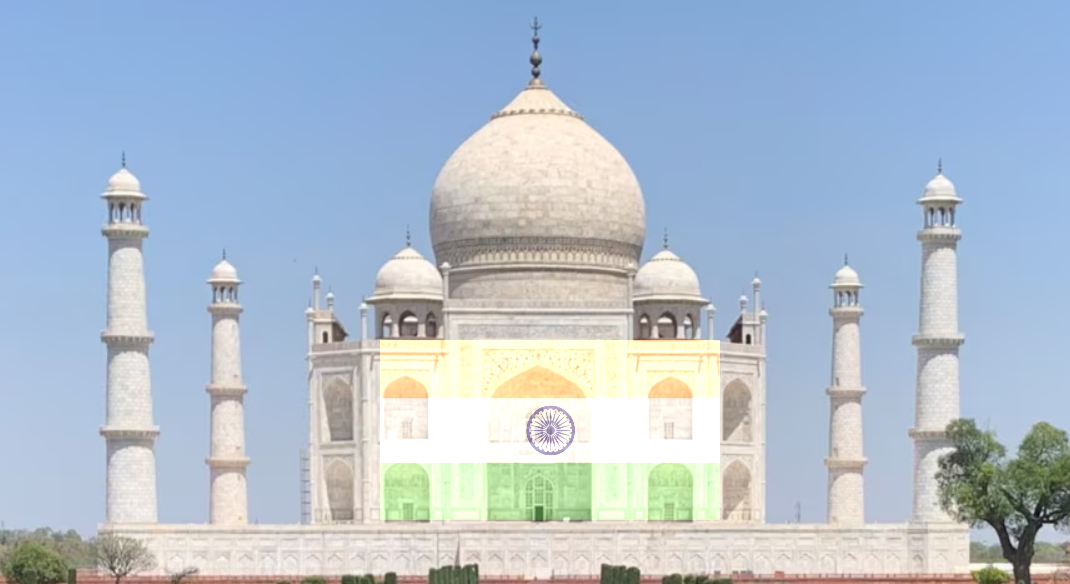

In [100]:

cv2_imshow(blended)